# 1. Deducing Causal Structure

Dense periodic n=1 causal structure. This notebook is Step 2 only. It uses the fixed dense periodic reference path, observable transition-time quantities, transparent nested OLS tests, and chronological random-forest ablations.


## 2. Scope causal vs predictive

The results are conditional predictive structures under the stated temporal ordering, not proof of intervention effects. No forecasting, weight estimation, transfer entropy, sparse-event work, or external data is included.


## 3. Observable timing

Each row is a source transition at time $t_i$. Features are $\sigma_i$, the observable price-shock proxy $r_i / \sigma_i$, and event-history indicators from the current event through the configured response-horizon age inherited from reference_timing; targets are $\sigma_{i+1}$, $\sigma_{i+1}-\sigma_i$, or the same-transition magnitude $r_i^2/dt_i$. Thus no feature is from the future of its target.


## 4. Load the reference simulation


In [2]:
%%capture
%run "./00_model_specification_and_core_simulator.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

pd.set_option('display.precision', 6)
alpha = 0.05
model_params = reference_config['model']
event_params = reference_config['events']
simulation_params = reference_config['simulation']
assert model_params['n'] == 1
reference_timing = reference_timing
steps_per_year = reference_timing['steps_per_year']
event_period_steps = reference_timing['event_period_steps']
response_horizon_steps = reference_timing['response_horizon_steps']
event_transition_ages = list(reference_timing['event_transition_ages'])
n_steps = simulation_params['years'] * steps_per_year
time_grid = np.arange(n_steps + 1, dtype=float) / steps_per_year
event_times = periodic_event_times(time_grid[0], time_grid[-2], event_params)
dense_result = simulate_event_volatility(
    time_grid=time_grid, S0=simulation_params['S0'], sigma0=simulation_params['sigma0'],
    n=model_params['n'], alpha_fn=alpha_fn, nu_fn=nu_fn, rho_fn=rho_fn,
    event_weight_fn=event_weight_fn, model_params=model_params, event_times=event_times,
    event_params=event_params, seed=simulation_params['seed'],
)
states = dense_result['states'].copy()
transitions = dense_result['transitions'].copy()
pd.testing.assert_frame_equal(states, reference_result['states'])
pd.testing.assert_frame_equal(transitions, reference_result['transitions'])
assert len(event_times) == int(transitions['event'].sum())
print(f'Regenerated {len(transitions)} transitions with {len(event_times)} source-time events.')


## 5. Build validate table


In [3]:
transition_table = pd.DataFrame({
    'i': transitions['i'].to_numpy(),
    't_i': transitions['t'].to_numpy(),
    'dt_i': transitions['dt'].to_numpy(),
    'S_i': states['S'].iloc[:-1].to_numpy(),
    'S_next': states['S'].iloc[1:].to_numpy(),
    'sigma_i': states['sigma'].iloc[:-1].to_numpy(),
    'sigma_next': states['sigma'].iloc[1:].to_numpy(),
    'event_i': transitions['event'].to_numpy(dtype=int),
})
transition_table['delta_sigma_next'] = transition_table['sigma_next'] - transition_table['sigma_i']
transition_table['simple_return_i'] = transition_table['S_next'] / transition_table['S_i'] - 1.0
transition_table['scaled_squared_return_i'] = transition_table['simple_return_i'] ** 2 / transition_table['dt_i']
transition_table['epsilon_proxy'] = transition_table['simple_return_i'] / transition_table['sigma_i']
for lag in event_transition_ages:
    transition_table[f'event_lag_{lag}'] = transition_table['event_i'].shift(lag)
event_features = [f'event_lag_{lag}' for lag in event_transition_ages]
causal_table = transition_table.dropna(subset=event_features).copy().reset_index(drop=True)
causal_table[event_features] = causal_table[event_features].astype(int)
causal_table['sigma_i_squared'] = causal_table['sigma_i'] ** 2

assert len(causal_table) == len(transition_table) - response_horizon_steps
assert np.array_equal(causal_table['i'].to_numpy(), np.arange(response_horizon_steps, len(transition_table)))
for lag in event_transition_ages:
    expected = transitions['event'].shift(lag).iloc[response_horizon_steps:].to_numpy(dtype=int)
    np.testing.assert_array_equal(causal_table[f'event_lag_{lag}'].to_numpy(), expected)
assert causal_table.replace([np.inf, -np.inf], np.nan).notna().all().all()
np.testing.assert_allclose(transition_table['epsilon_proxy'], transitions['epsilon'], rtol=0.0, atol=1e-12)
observed_feature_columns = {'sigma_i', 'epsilon_proxy', 'sigma_i_squared', *event_features}
hidden_names = {'epsilon', 'eta', 'F', 'omega_next', 'event_multiplier', 'alpha', 'nu', 'rho', 'x_next'}
assert observed_feature_columns.isdisjoint(hidden_names)
assert not any(name in causal_table.columns for name in hidden_names)
assert (causal_table['event_lag_0'] == causal_table['event_i']).all()
print(f'Usable, fully observed transition rows: {len(causal_table)}')
causal_table.head()


Usable, fully observed transition rows: 492


,i,t_i,dt_i,S_i,S_next,sigma_i,sigma_next,event_i,delta_sigma_next,simple_return_i,...,event_lag_4,event_lag_5,event_lag_6,event_lag_7,event_lag_8,event_lag_9,event_lag_10,event_lag_11,event_lag_12,sigma_i_squared
0,12,0.047619,0.003968,102.751010,102.087857,0.195601,0.195878,0,0.000277,-0.006454,...,0,0,0,0,0,0,0,0,0,0.038260
1,13,0.051587,0.003968,102.087857,102.490211,0.195878,0.196371,0,0.000494,0.003941,...,0,0,0,0,0,0,0,0,0,0.038368
2,14,0.055556,0.003968,102.490211,101.771270,0.196371,0.195697,0,-0.000675,-0.007015,...,0,0,0,0,0,0,0,0,0,0.038562
3,15,0.059524,0.003968,101.771270,100.296205,0.195697,0.195363,0,-0.000334,-0.014494,...,0,0,0,0,0,0,0,0,0,0.038297
4,16,0.063492,0.003968,100.296205,100.888858,0.195363,0.194100,0,-0.001263,0.005909,...,0,0,0,0,0,0,0,0,0,0.038167


## 6. Expected withheld

The expected graph is withheld until after fitting: current volatility affects next volatility and price-movement magnitude; the current observable price shock affects next volatility; event history affects next volatility. Conditional on current volatility, a direct event-to-current-price-magnitude edge is expected to be absent.


## 7. Parametric methodology

For each prespecified feature group, a restricted OLS regression omits that group and an unrestricted OLS regression includes it. With q omitted coefficients, $F=((RSS_{restricted}-RSS_{full})/q)/(RSS_{full}/df_{resid})$. The p-value is the upper-tail F probability. Partial R-squared is $1-RSS_{full}/RSS_{restricted}$. Coefficients, standard errors, and 95% confidence intervals are from the unrestricted model. A statsmodels linear-restriction F test validates the manual calculation.


In [4]:
def nested_group_f_test(data, target, full_features, removed_features):
    if not set(removed_features).issubset(full_features):
        raise ValueError('Removed features must be a subset of full features.')
    kept_features = [f for f in full_features if f not in removed_features]
    y = data[target].to_numpy(dtype=float)
    full_model = sm.OLS(y, sm.add_constant(data[full_features], has_constant='add')).fit()
    reduced_model = sm.OLS(y, sm.add_constant(data[kept_features], has_constant='add')).fit()
    rss_full, rss_reduced = float(full_model.ssr), float(reduced_model.ssr)
    q, residual_df = len(removed_features), int(full_model.df_resid)
    if rss_reduced + 1e-10 < rss_full or residual_df <= 0 or q <= 0:
        raise AssertionError('Invalid nested-regression geometry.')
    f_stat = ((rss_reduced - rss_full) / q) / (rss_full / residual_df)
    p_value = float(stats.f.sf(f_stat, q, residual_df))
    restriction = np.zeros((q, len(full_model.params)))
    for row, feature in enumerate(removed_features):
        restriction[row, full_model.params.index.get_loc(feature)] = 1.0
    numerical_check = full_model.f_test(restriction)
    if not np.isclose(f_stat, float(numerical_check.fvalue), rtol=1e-9, atol=1e-9):
        raise AssertionError('Manual and statsmodels F statistics disagree.')
    return {
        'target': target, 'tested_group': ', '.join(removed_features), 'nobs': int(full_model.nobs),
        'q': q, 'rss_reduced': rss_reduced, 'rss_full': rss_full, 'F': float(f_stat),
        'p_value': p_value, 'partial_R2': float(1.0 - rss_full / rss_reduced),
        'residual_df': residual_df, 'rank_full': int(np.linalg.matrix_rank(full_model.model.exog)),
        'statsmodels_F': float(numerical_check.fvalue), 'statsmodels_p_value': float(numerical_check.pvalue),
        'full_model': full_model, 'reduced_model': reduced_model,
    }

def run_parametric_groups(data, target, features, groups):
    records, models = [], {}
    for group, removed in groups.items():
        result = nested_group_f_test(data, target, features, removed)
        models[group] = result.pop('full_model')
        result.pop('reduced_model')
        result['group'] = group
        records.append(result)
    return pd.DataFrame(records), models

def coefficient_summary(model, selected_features):
    ci = model.conf_int(alpha=0.05)
    return pd.DataFrame({
        'coefficient': model.params[selected_features], 'standard_error': model.bse[selected_features],
        'CI_low': ci.loc[selected_features, 0], 'CI_high': ci.loc[selected_features, 1],
    })


## 8. Param vol-level


,group,nobs,q,F,p_value,partial_R2,residual_df,rank_full
0,state,492,1,182338.894631,0.000000e+00,0.997396,476,16
1,price_shock,492,1,85.254674,8.661196e-19,0.151900,476,16
2,events,492,13,6.773734,5.244700e-12,0.156116,476,16


,coefficient,standard_error,CI_low,CI_high
sigma_i,0.996185,0.002333,0.991601,1.000769
epsilon_proxy,-0.005810,0.000629,-0.007046,-0.004573


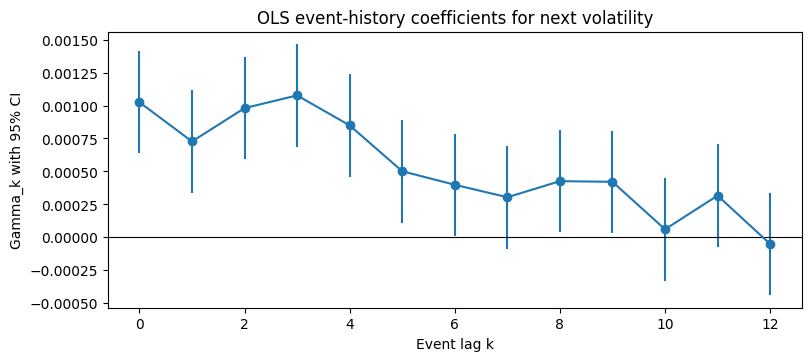

In [5]:
level_features = ['sigma_i', 'epsilon_proxy', *event_features]
level_groups = {'state': ['sigma_i'], 'price_shock': ['epsilon_proxy'], 'events': event_features}
level_parametric, level_models = run_parametric_groups(causal_table, 'sigma_next', level_features, level_groups)
level_coefficients = coefficient_summary(level_models['state'], level_features)
display(level_parametric[['group', 'nobs', 'q', 'F', 'p_value', 'partial_R2', 'residual_df', 'rank_full']])
display(level_coefficients.loc[['sigma_i', 'epsilon_proxy']])

gamma = level_coefficients.loc[event_features].copy()
gamma['lag'] = np.asarray(event_transition_ages)
fig, axis = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
axis.errorbar(gamma['lag'], gamma['coefficient'], yerr=[gamma['coefficient']-gamma['CI_low'], gamma['CI_high']-gamma['coefficient']], fmt='o-')
axis.axhline(0.0, color='black', linewidth=0.8)
axis.set(title='OLS event-history coefficients for next volatility', xlabel='Event lag k', ylabel='Gamma_k with 95% CI')
plt.show()


## 9. Param vol-change

The price-shock and event-history F tests are identical here for sigma_next and delta_sigma_next because delta_sigma_next = sigma_next - sigma_i and sigma_i is included in both the full and reduced regressions. Subtracting sigma_i changes its own coefficient, but leaves the relevant fitted residuals unchanged.


In [6]:
change_parametric, change_models = run_parametric_groups(causal_table, 'delta_sigma_next', level_features, level_groups)
change_coefficients = coefficient_summary(change_models['state'], ['sigma_i', 'epsilon_proxy'])
display(change_parametric[['group', 'nobs', 'q', 'F', 'p_value', 'partial_R2']])
display(change_coefficients)


,group,nobs,q,F,p_value,partial_R2
0,state,492,1,2.673618,1.026849e-01,0.005585
1,price_shock,492,1,85.254674,8.661196e-19,0.151900
2,events,492,13,6.773734,5.244700e-12,0.156116


,coefficient,standard_error,CI_low,CI_high
sigma_i,-0.003815,0.002333,-0.008399,0.000769
epsilon_proxy,-0.005810,0.000629,-0.007046,-0.004573


## 10. Param price movement

The magnitude target is scaled squared return, not raw return or price. Its state predictor is sigma_i squared, consistent with the transition-scale relationship.


In [7]:
magnitude_features = ['sigma_i_squared', *event_features]
magnitude_groups = {'state': ['sigma_i_squared'], 'events': event_features}
magnitude_parametric, magnitude_models = run_parametric_groups(causal_table, 'scaled_squared_return_i', magnitude_features, magnitude_groups)
magnitude_coefficients = coefficient_summary(magnitude_models['state'], ['sigma_i_squared'])
display(magnitude_parametric[['group', 'nobs', 'q', 'F', 'p_value', 'partial_R2']])
display(magnitude_coefficients)


,group,nobs,q,F,p_value,partial_R2
0,state,492,1,5.284261,0.021950,0.010957
1,events,492,13,0.967115,0.482975,0.025681


,coefficient,standard_error,CI_low,CI_high
sigma_i_squared,1.067934,0.464571,0.155075,1.980793


## 11. Param inferred edge table


In [8]:
parametric_edge_table = pd.DataFrame([
    ('Current volatility -> next volatility', level_parametric, 'state'),
    ('Observed price shock -> next volatility', level_parametric, 'price_shock'),
    ('Event history -> next volatility', level_parametric, 'events'),
    ('Current volatility -> volatility change', change_parametric, 'state'),
    ('Observed price shock -> volatility change', change_parametric, 'price_shock'),
    ('Event history -> volatility change', change_parametric, 'events'),
    ('Current volatility -> price magnitude', magnitude_parametric, 'state'),
    ('Event history -> price magnitude', magnitude_parametric, 'events'),
], columns=['edge', 'table', 'group'])
parametric_edge_table['F'] = [row.table.loc[row.table['group'].eq(row.group), 'F'].iloc[0] for row in parametric_edge_table.itertuples()]
parametric_edge_table['p_value'] = [row.table.loc[row.table['group'].eq(row.group), 'p_value'].iloc[0] for row in parametric_edge_table.itertuples()]
parametric_edge_table['partial_R2'] = [row.table.loc[row.table['group'].eq(row.group), 'partial_R2'].iloc[0] for row in parametric_edge_table.itertuples()]
parametric_edge_table['supported'] = (parametric_edge_table['p_value'] < alpha) & (parametric_edge_table['partial_R2'] > 0)
parametric_edge_table = parametric_edge_table.drop(columns=['table', 'group'])
display(parametric_edge_table)


,edge,F,p_value,partial_R2,supported
0,Current volatility -> next volatility,182338.894631,0.000000e+00,0.997396,True
1,Observed price shock -> next volatility,85.254674,8.661196e-19,0.151900,True
2,Event history -> next volatility,6.773734,5.244700e-12,0.156116,True
3,Current volatility -> volatility change,2.673618,1.026849e-01,0.005585,False
4,Observed price shock -> volatility change,85.254674,8.661196e-19,0.151900,True
5,Event history -> volatility change,6.773734,5.244700e-12,0.156116,True
6,Current volatility -> price magnitude,5.284261,2.195050e-02,0.010957,True
7,Event history -> price magnitude,0.967115,4.829747e-01,0.025681,False


## 12. Nonparam methodology

A fixed RandomForestRegressor is evaluated on five chronological TimeSeriesSplit folds without shuffling. Each target uses the same folds and configuration for the full model and its group ablations. Improvement is RMSE_reduced - RMSE_full: supported means positive mean improvement and at least four of five positive folds; mixed means positive average only; otherwise it is not supported. Positivity uses a tolerance of 1e-10.

Each event-lag dummy has only 3-4 positive observations in the first chronological training fold. min_samples_leaf=8 structurally prevents a tree from splitting on such a sparse event-lag feature in that fold. The fixed, untuned value min_samples_leaf=3 gives the forest capacity to evaluate those binary event-history features in every training fold; it does not force any resulting classification.


In [9]:
rf_parameters = {
    'n_estimators': 300, 'max_depth': 6, 'min_samples_leaf': 3, 'max_features': 1.0,
    'random_state': 20260724, 'n_jobs': -1,
}
improvement_tolerance = 1e-10
folds = list(TimeSeriesSplit(n_splits=5).split(causal_table))
fold_coverage_rows = []
for fold, (train_index, test_index) in enumerate(folds, start=1):
    train, test = causal_table.iloc[train_index], causal_table.iloc[test_index]
    event_positive_counts = train[event_features].sum()
    fold_coverage_rows.append({
        'fold': fold, 'training_rows': len(train), 'validation_rows': len(test),
        'minimum_event_lag_positives': int(event_positive_counts.min()),
        'maximum_event_lag_positives': int(event_positive_counts.max()),
        'exact_events_in_validation': int(test['event_i'].sum()),
    })
    assert train_index.max() < test_index.min()
    assert test['event_i'].sum() >= 1
fold_event_coverage = pd.DataFrame(fold_coverage_rows)
insufficient_folds = fold_event_coverage.loc[
    fold_event_coverage['minimum_event_lag_positives']
    < rf_parameters['min_samples_leaf']
]
if not insufficient_folds.empty:
    raise ValueError(
        'At least one chronological RF training fold has fewer positive '
        'event-lag observations than min_samples_leaf. '
        f'Problematic folds: {insufficient_folds.to_dict("records")}'
    )
assert rf_parameters['min_samples_leaf'] == 3
display(fold_event_coverage)
print('min_samples_leaf=3 permits an event-feature split in every chronological training fold.')

def random_forest_ablations(data, target, full_features, groups, target_label):
    rows = []
    for fold, (train_index, test_index) in enumerate(folds, start=1):
        train, test = data.iloc[train_index], data.iloc[test_index]
        y_train, y_test = train[target], test[target]
        full = RandomForestRegressor(**rf_parameters).fit(train[full_features], y_train)
        full_prediction = full.predict(test[full_features])
        full_rmse = float(np.sqrt(mean_squared_error(y_test, full_prediction)))
        full_mae = float(mean_absolute_error(y_test, full_prediction))
        rows.append({'target': target_label, 'fold': fold, 'model': 'full', 'RMSE': full_rmse, 'MAE': full_mae, 'rmse_improvement': 0.0, 'mae_improvement': 0.0})
        for group, removed in groups.items():
            kept = [f for f in full_features if f not in removed]
            ablated = RandomForestRegressor(**rf_parameters).fit(train[kept], y_train)
            prediction = ablated.predict(test[kept])
            rmse = float(np.sqrt(mean_squared_error(y_test, prediction)))
            mae = float(mean_absolute_error(y_test, prediction))
            rows.append({'target': target_label, 'fold': fold, 'model': f'no {group}', 'RMSE': rmse, 'MAE': mae, 'rmse_improvement': rmse - full_rmse, 'mae_improvement': mae - full_mae})
    return pd.DataFrame(rows)

def summarise_rf(ablations):
    summary = ablations.groupby(['target', 'model'], as_index=False).agg(
        mean_RMSE=('RMSE', 'mean'), std_RMSE=('RMSE', 'std'), mean_MAE=('MAE', 'mean'),
        mean_rmse_improvement=('rmse_improvement', 'mean'),
        median_rmse_improvement=('rmse_improvement', 'median'),
        std_rmse_improvement=('rmse_improvement', 'std'),
        mean_mae_improvement=('mae_improvement', 'mean'),
        positive_rmse_improvement_folds=('rmse_improvement', lambda x: int((x > improvement_tolerance).sum())),
    )
    summary['evidence'] = np.select(
        [(summary['mean_rmse_improvement'] > improvement_tolerance) & (summary['positive_rmse_improvement_folds'] >= 4), summary['mean_rmse_improvement'] > improvement_tolerance],
        ['supported', 'mixed'], default='not supported',
    )
    return summary


,fold,training_rows,validation_rows,minimum_event_lag_positives,maximum_event_lag_positives,exact_events_in_validation
0,1,82,82,3,4,4
1,2,164,82,7,8,4
2,3,246,82,11,12,4
3,4,328,82,15,16,4
4,5,410,82,19,20,3


min_samples_leaf=3 permits an event-feature split in every chronological training fold.


## 13. RF level ablation


In [10]:
rf_level_folds = random_forest_ablations(causal_table, 'sigma_next', level_features, level_groups, 'next volatility')
rf_level_summary = summarise_rf(rf_level_folds)
display(rf_level_folds)
display(rf_level_summary)


,target,fold,model,RMSE,MAE,rmse_improvement,mae_improvement
0,next volatility,1,full,0.004767,0.004089,0.000000e+00,0.000000e+00
1,next volatility,1,no state,0.014245,0.013336,9.477743e-03,9.247649e-03
2,next volatility,1,no price_shock,0.004626,0.003922,-1.409266e-04,-1.663322e-04
3,next volatility,1,no events,0.004767,0.004089,-4.644860e-08,-2.406243e-08
4,next volatility,2,full,0.006273,0.005350,0.000000e+00,0.000000e+00
5,next volatility,2,no state,0.016342,0.015573,1.006990e-02,1.022299e-02
6,next volatility,2,no price_shock,0.005875,0.004934,-3.973754e-04,-4.159980e-04
7,next volatility,2,no events,0.006273,0.005352,8.579831e-07,2.034701e-06
8,next volatility,3,full,0.005211,0.004702,0.000000e+00,0.000000e+00
9,next volatility,3,no state,0.021772,0.021489,1.656056e-02,1.678700e-02


,target,model,mean_RMSE,std_RMSE,mean_MAE,mean_rmse_improvement,median_rmse_improvement,std_rmse_improvement,mean_mae_improvement,positive_rmse_improvement_folds,evidence
0,next volatility,full,0.005190,0.001584,0.004263,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0,not supported
1,next volatility,no events,0.005189,0.001584,0.004263,-6.186959e-07,-4.644860e-08,0.000002,-1.701312e-07,2,not supported
2,next volatility,no price_shock,0.005046,0.001502,0.004115,-1.442421e-04,-1.362784e-04,0.000153,-1.486122e-04,0,not supported
3,next volatility,no state,0.021066,0.005962,0.020466,1.587572e-02,1.656056e-02,0.006817,1.620271e-02,5,supported


## 14. Change ablation


In [11]:
rf_change_folds = random_forest_ablations(causal_table, 'delta_sigma_next', level_features, level_groups, 'volatility change')
rf_change_summary = summarise_rf(rf_change_folds)
display(rf_change_folds)
display(rf_change_summary)


,target,fold,model,RMSE,MAE,rmse_improvement,mae_improvement
0,volatility change,1,full,0.001002,0.000800,0.000000,0.000000
1,volatility change,1,no state,0.001061,0.000862,0.000060,0.000061
2,volatility change,1,no price_shock,0.001159,0.000942,0.000157,0.000142
3,volatility change,1,no events,0.001017,0.000815,0.000015,0.000014
4,volatility change,2,full,0.001092,0.000917,0.000000,0.000000
5,volatility change,2,no state,0.000970,0.000822,-0.000122,-0.000095
6,volatility change,2,no price_shock,0.001002,0.000834,-0.000090,-0.000083
7,volatility change,2,no events,0.001120,0.000941,0.000028,0.000024
8,volatility change,3,full,0.001011,0.000823,0.000000,0.000000
9,volatility change,3,no state,0.001039,0.000847,0.000028,0.000024


,target,model,mean_RMSE,std_RMSE,mean_MAE,mean_rmse_improvement,median_rmse_improvement,std_rmse_improvement,mean_mae_improvement,positive_rmse_improvement_folds,evidence
0,volatility change,full,0.001002,0.000058,0.000817,0.000000,0.000000,0.000000,0.000000,0,not supported
1,volatility change,no events,0.001039,0.000051,0.000849,0.000037,0.000028,0.000022,0.000033,5,supported
2,volatility change,no price_shock,0.001065,0.000083,0.000867,0.000063,0.000092,0.000109,0.000051,3,mixed
3,volatility change,no state,0.000985,0.000065,0.000809,-0.000017,-0.000015,0.000069,-0.000008,2,not supported


## 15. Price ablation


,target,fold,model,RMSE,MAE,rmse_improvement,mae_improvement
0,price magnitude,1,full,0.083165,0.041940,0.000000,0.000000
1,price magnitude,1,no state,0.075183,0.047959,-0.007982,0.006019
2,price magnitude,1,no events,0.084547,0.043421,0.001382,0.001480
3,price magnitude,2,full,0.084712,0.061872,0.000000,0.000000
4,price magnitude,2,no state,0.084634,0.054522,-0.000078,-0.007350
5,price magnitude,2,no events,0.084690,0.060542,-0.000022,-0.001330
6,price magnitude,3,full,0.099822,0.078472,0.000000,0.000000
7,price magnitude,3,no state,0.100481,0.066440,0.000660,-0.012033
8,price magnitude,3,no events,0.099688,0.078050,-0.000134,-0.000422
9,price magnitude,4,full,0.114043,0.096946,0.000000,0.000000


,target,model,mean_RMSE,std_RMSE,mean_MAE,mean_rmse_improvement,median_rmse_improvement,std_rmse_improvement,mean_mae_improvement,positive_rmse_improvement_folds,evidence
0,price magnitude,full,0.098455,0.014260,0.074759,0.000000,0.000000,0.000000,0.000000,0,not supported
1,price magnitude,no events,0.099776,0.015206,0.075554,0.001320,0.001382,0.001425,0.000794,3,mixed
2,price magnitude,no state,0.085717,0.009346,0.057362,-0.012738,-0.007982,0.014802,-0.017398,1,not supported


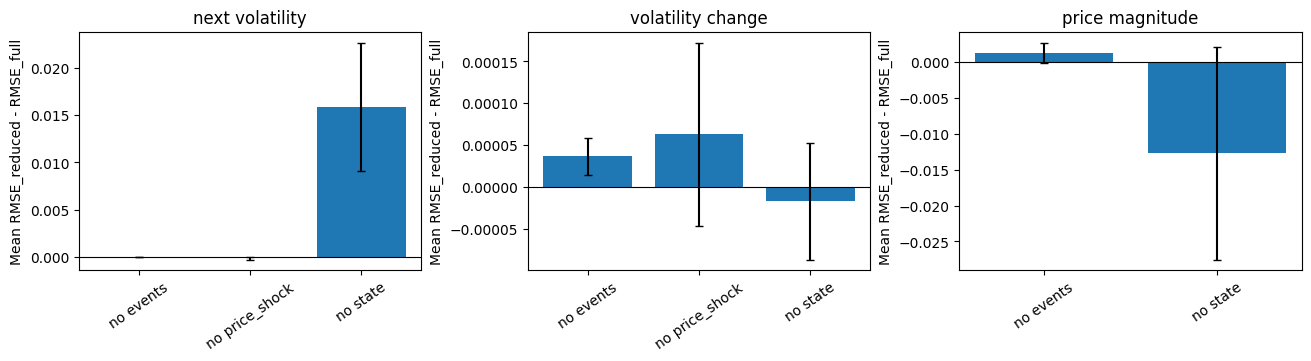

In [12]:
rf_magnitude_folds = random_forest_ablations(causal_table, 'scaled_squared_return_i', magnitude_features, magnitude_groups, 'price magnitude')
rf_magnitude_summary = summarise_rf(rf_magnitude_folds)
display(rf_magnitude_folds)
display(rf_magnitude_summary)

rf_summaries = pd.concat([rf_level_summary, rf_change_summary, rf_magnitude_summary], ignore_index=True)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
for axis, target in zip(axes, ['next volatility', 'volatility change', 'price magnitude']):
    subset = rf_summaries[rf_summaries['target'].eq(target) & rf_summaries['model'].ne('full')]
    axis.bar(subset['model'], subset['mean_rmse_improvement'], yerr=subset['std_rmse_improvement'], capsize=3)
    axis.axhline(0.0, color='black', linewidth=0.8)
    axis.tick_params(axis='x', rotation=35)
    axis.set(title=target, ylabel='Mean RMSE_reduced - RMSE_full')
plt.show()


## 16. Nonparam edge table


In [13]:
nonparametric_edge_table = pd.DataFrame([
    ('Current volatility -> next volatility', 'next volatility', 'no state'),
    ('Observed price shock -> next volatility', 'next volatility', 'no price_shock'),
    ('Event history -> next volatility', 'next volatility', 'no events'),
    ('Current volatility -> volatility change', 'volatility change', 'no state'),
    ('Observed price shock -> volatility change', 'volatility change', 'no price_shock'),
    ('Event history -> volatility change', 'volatility change', 'no events'),
    ('Current volatility -> price magnitude', 'price magnitude', 'no state'),
    ('Event history -> price magnitude', 'price magnitude', 'no events'),
], columns=['edge', 'target', 'ablation'])
nonparametric_edge_table = nonparametric_edge_table.merge(
    rf_summaries[['target', 'model', 'mean_rmse_improvement', 'median_rmse_improvement', 'std_rmse_improvement', 'mean_mae_improvement', 'positive_rmse_improvement_folds', 'evidence']],
    left_on=['target', 'ablation'], right_on=['target', 'model'], how='left', validate='one_to_one',
).drop(columns=['model'])
nonparametric_edge_table['supported'] = nonparametric_edge_table['evidence'].eq('supported')
display(nonparametric_edge_table)


,edge,target,ablation,mean_rmse_improvement,median_rmse_improvement,std_rmse_improvement,mean_mae_improvement,positive_rmse_improvement_folds,evidence,supported
0,Current volatility -> next volatility,next volatility,no state,1.587572e-02,1.656056e-02,0.006817,1.620271e-02,5,supported,True
1,Observed price shock -> next volatility,next volatility,no price_shock,-1.442421e-04,-1.362784e-04,0.000153,-1.486122e-04,0,not supported,False
2,Event history -> next volatility,next volatility,no events,-6.186959e-07,-4.644860e-08,0.000002,-1.701312e-07,2,not supported,False
3,Current volatility -> volatility change,volatility change,no state,-1.708855e-05,-1.461605e-05,0.000069,-7.698179e-06,2,not supported,False
4,Observed price shock -> volatility change,volatility change,no price_shock,6.320408e-05,9.188451e-05,0.000109,5.050906e-05,3,mixed,False
5,Event history -> volatility change,volatility change,no events,3.689955e-05,2.849959e-05,0.000022,3.273756e-05,5,supported,True
6,Current volatility -> price magnitude,price magnitude,no state,-1.273784e-02,-7.982121e-03,0.014802,-1.739772e-02,1,not supported,False
7,Event history -> price magnitude,price magnitude,no events,1.320331e-03,1.382229e-03,0.001425,7.944236e-04,3,mixed,False


## 17. Known structure comparison


In [14]:
expected_edges = {
    'Current volatility -> next volatility': True,
    'Observed price shock -> next volatility': True,
    'Event history -> next volatility': True,
    'Current volatility -> volatility change': True,
    'Observed price shock -> volatility change': True,
    'Event history -> volatility change': True,
    'Current volatility -> price magnitude': True,
    'Event history -> price magnitude': False,
}
comparison_table = parametric_edge_table.merge(
    nonparametric_edge_table[['edge', 'supported', 'evidence']], on='edge', suffixes=('_parametric', '_nonparametric'), validate='one_to_one'
)
comparison_table['expected'] = comparison_table['edge'].map(expected_edges)
def agreement(row):
    p, n, expected = row['supported_parametric'], row['supported_nonparametric'], row['expected']
    if expected and p and n: return 'both recover expected'
    if expected and p: return 'parametric only'
    if expected and n: return 'nonparametric only'
    if expected: return 'neither'
    if not p and not n: return 'expected absence recovered'
    return 'false positive'
comparison_table['agreement'] = comparison_table.apply(agreement, axis=1)
display(comparison_table[['edge', 'expected', 'supported_parametric', 'supported_nonparametric', 'agreement']])


,edge,expected,supported_parametric,supported_nonparametric,agreement
0,Current volatility -> next volatility,True,True,True,both recover expected
1,Observed price shock -> next volatility,True,True,False,parametric only
2,Event history -> next volatility,True,True,False,parametric only
3,Current volatility -> volatility change,True,False,False,neither
4,Observed price shock -> volatility change,True,True,False,parametric only
5,Event history -> volatility change,True,True,True,both recover expected
6,Current volatility -> price magnitude,True,True,False,parametric only
7,Event history -> price magnitude,False,False,False,expected absence recovered


## 18. Combined diagram


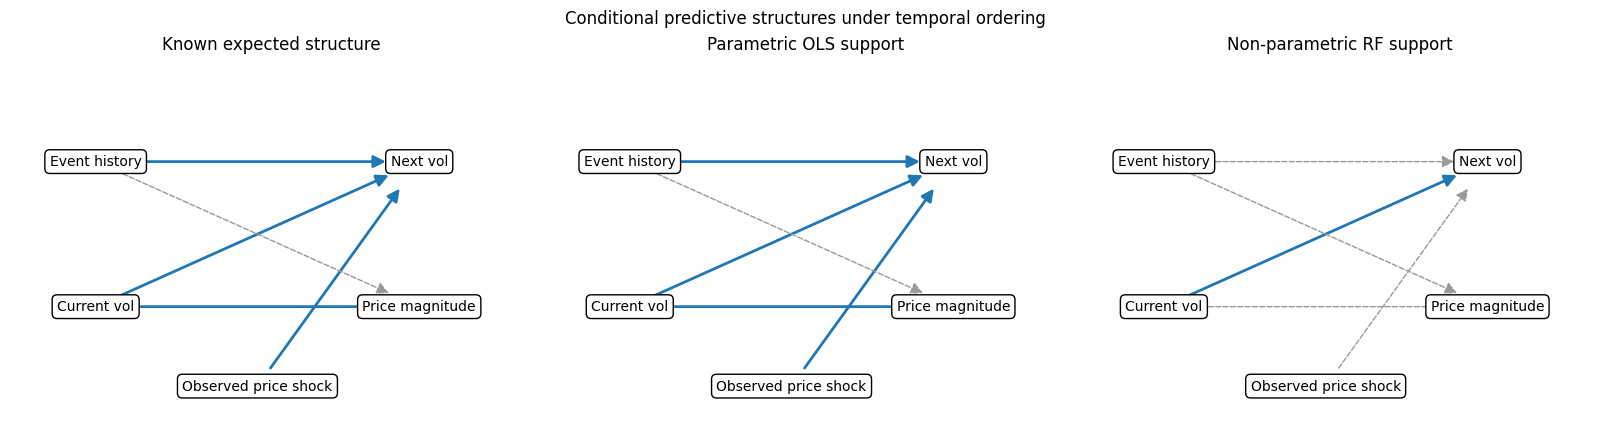

In [15]:
from matplotlib.patches import FancyArrowPatch

diagram_edges = [
    ('Current volatility -> next volatility', 'Current vol', 'Next vol'),
    ('Observed price shock -> next volatility', 'Observed price shock', 'Next vol'),
    ('Event history -> next volatility', 'Event history', 'Next vol'),
    ('Current volatility -> price magnitude', 'Current vol', 'Price magnitude'),
    ('Event history -> price magnitude', 'Event history', 'Price magnitude'),
]
positions = {'Event history': (0.08, 0.70), 'Current vol': (0.08, 0.28), 'Observed price shock': (0.42, 0.05), 'Price magnitude': (0.76, 0.28), 'Next vol': (0.76, 0.70)}
def draw_structure(axis, title, support_map):
    for label, (x, y) in positions.items():
        axis.text(x, y, label, ha='center', va='center', bbox={'boxstyle':'round,pad=0.35', 'fc':'white', 'ec':'black'})
    for edge, source, target in diagram_edges:
        x1, y1, x2, y2 = *positions[source], *positions[target]
        supported = support_map.get(edge, False)
        axis.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=18,
            shrinkA=16, shrinkB=24, connectionstyle='arc3,rad=0.0', zorder=1,
            linewidth=2 if supported else 1, linestyle='-' if supported else '--', color='tab:blue' if supported else '0.6'))
    axis.set(title=title, xlim=(-0.1, 1.0), ylim=(-0.08, 1.0))
    axis.axis('off')
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), constrained_layout=True)
draw_structure(axes[0], 'Known expected structure', expected_edges)
draw_structure(axes[1], 'Parametric OLS support', dict(zip(parametric_edge_table['edge'], parametric_edge_table['supported'])))
draw_structure(axes[2], 'Non-parametric RF support', dict(zip(nonparametric_edge_table['edge'], nonparametric_edge_table['supported'])))
fig.suptitle('Conditional predictive structures under temporal ordering')
plt.show()


## 19. Findings Step 2 conclusion


In [16]:
def edge_status(edge):
    row = comparison_table.loc[comparison_table['edge'].eq(edge)].iloc[0]
    return row['agreement']

expected_both = comparison_table.loc[comparison_table['expected'] & comparison_table['agreement'].eq('both recover expected'), 'edge'].tolist()
one_method = comparison_table.loc[comparison_table['expected'] & comparison_table['agreement'].isin(['parametric only', 'nonparametric only']), ['edge', 'agreement']]
false_positives = comparison_table.loc[comparison_table['agreement'].eq('false positive'), 'edge'].tolist()
absence_status = edge_status('Event history -> price magnitude')
parametric_recovered = parametric_edge_table.loc[parametric_edge_table['supported'], 'edge'].tolist()
rf_recovered = nonparametric_edge_table.loc[nonparametric_edge_table['supported'], 'edge'].tolist()
print(f'Usable rows: {len(causal_table)}')
print('Parametric edge table:')
display(parametric_edge_table[['edge', 'supported', 'F', 'p_value', 'partial_R2']])
print('Non-parametric edge table:')
display(nonparametric_edge_table[['edge', 'supported', 'mean_rmse_improvement', 'median_rmse_improvement', 'std_rmse_improvement', 'mean_mae_improvement', 'positive_rmse_improvement_folds', 'evidence']])
print(f'Expected edges recovered by both methods: {expected_both}')
display(one_method)
print(f'False positives: {false_positives}')
print(f'Expected direct event-to-current-price-magnitude absence: {absence_status}')
print(f'Parametric OLS recovers: {parametric_recovered}')
print(f'Revised RF recovers: {rf_recovered}')
print('RF can still miss weak edges because the event-history dummies remain sparse and the fixed chronological folds provide limited positive examples; the leaf-size revision supplies capacity but does not guarantee recovery.')
print('Scaled squared returns are a noisy price-magnitude target because a single squared shock has high sampling variation.')
print('The level and change OLS group tests are partly algebraically redundant: with sigma_i in both nested designs, subtracting sigma_i preserves the price-shock and event-history residual comparisons.')
print('All features are observable and source-time aligned; no hidden simulator quantity and no event weight was used as a feature or estimated.')
print('All listed timing, nesting, rank, F-statistic, and chronological-fold validations passed.')
print('Caveat: this one fixed simulated path supports conditional temporal-predictive comparisons, not intervention claims or generalisation beyond this calibration.')


Usable rows: 492
Parametric edge table:


,edge,supported,F,p_value,partial_R2
0,Current volatility -> next volatility,True,182338.894631,0.000000e+00,0.997396
1,Observed price shock -> next volatility,True,85.254674,8.661196e-19,0.151900
2,Event history -> next volatility,True,6.773734,5.244700e-12,0.156116
3,Current volatility -> volatility change,False,2.673618,1.026849e-01,0.005585
4,Observed price shock -> volatility change,True,85.254674,8.661196e-19,0.151900
5,Event history -> volatility change,True,6.773734,5.244700e-12,0.156116
6,Current volatility -> price magnitude,True,5.284261,2.195050e-02,0.010957
7,Event history -> price magnitude,False,0.967115,4.829747e-01,0.025681


Non-parametric edge table:


,edge,supported,mean_rmse_improvement,median_rmse_improvement,std_rmse_improvement,mean_mae_improvement,positive_rmse_improvement_folds,evidence
0,Current volatility -> next volatility,True,1.587572e-02,1.656056e-02,0.006817,1.620271e-02,5,supported
1,Observed price shock -> next volatility,False,-1.442421e-04,-1.362784e-04,0.000153,-1.486122e-04,0,not supported
2,Event history -> next volatility,False,-6.186959e-07,-4.644860e-08,0.000002,-1.701312e-07,2,not supported
3,Current volatility -> volatility change,False,-1.708855e-05,-1.461605e-05,0.000069,-7.698179e-06,2,not supported
4,Observed price shock -> volatility change,False,6.320408e-05,9.188451e-05,0.000109,5.050906e-05,3,mixed
5,Event history -> volatility change,True,3.689955e-05,2.849959e-05,0.000022,3.273756e-05,5,supported
6,Current volatility -> price magnitude,False,-1.273784e-02,-7.982121e-03,0.014802,-1.739772e-02,1,not supported
7,Event history -> price magnitude,False,1.320331e-03,1.382229e-03,0.001425,7.944236e-04,3,mixed


Expected edges recovered by both methods: ['Current volatility -> next volatility', 'Event history -> volatility change']


,edge,agreement
1,Observed price shock -> next volatility,parametric only
2,Event history -> next volatility,parametric only
4,Observed price shock -> volatility change,parametric only
6,Current volatility -> price magnitude,parametric only


False positives: []
Expected direct event-to-current-price-magnitude absence: expected absence recovered
Parametric OLS recovers: ['Current volatility -> next volatility', 'Observed price shock -> next volatility', 'Event history -> next volatility', 'Observed price shock -> volatility change', 'Event history -> volatility change', 'Current volatility -> price magnitude']
Revised RF recovers: ['Current volatility -> next volatility', 'Event history -> volatility change']
RF can still miss weak edges because the event-history dummies remain sparse and the fixed chronological folds provide limited positive examples; the leaf-size revision supplies capacity but does not guarantee recovery.
Scaled squared returns are a noisy price-magnitude target because a single squared shock has high sampling variation.
The level and change OLS group tests are partly algebraically redundant: with sigma_i in both nested designs, subtracting sigma_i preserves the price-shock and event-history residual com